{'0000': 515, '1111': 509}


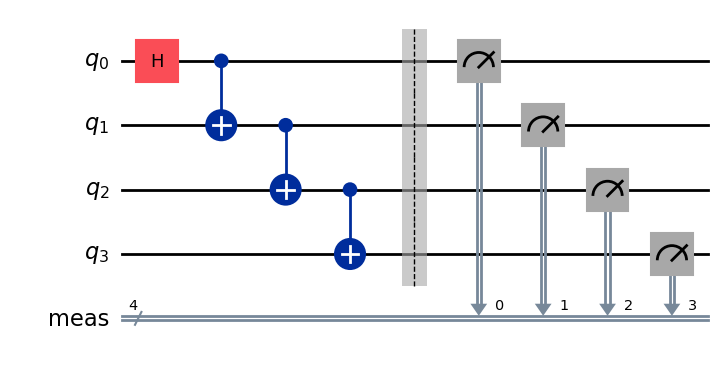

In [32]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram


qc=QuantumCircuit(4)

qc.h(0)
qc.cx(0,1)
qc.cx(1,2)
qc.cx(2,3)
qc.measure_all()


sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())



counts = result[0].data.meas.get_counts()
plot_histogram(counts)

qc.draw(output="mpl", idle_wires=False, style="iqp")

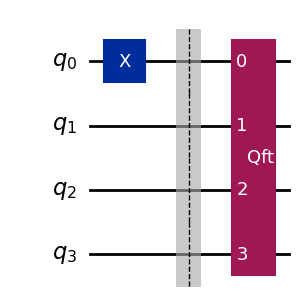

In [33]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFTGate
from qiskit import transpile

bits=4
qrec_q=QuantumRegister(bits+1, 'q')
crec_c=ClassicalRegister(bits, 'c')
qc=QuantumCircuit(qrec_q, crec_c)

qc.x(qrec_q[0])

qc.barrier()
    
qc=qc.compose(QFTGate(bits),[x for x in range(bits)])

qc.draw(output="mpl", idle_wires=False, style="iqp")

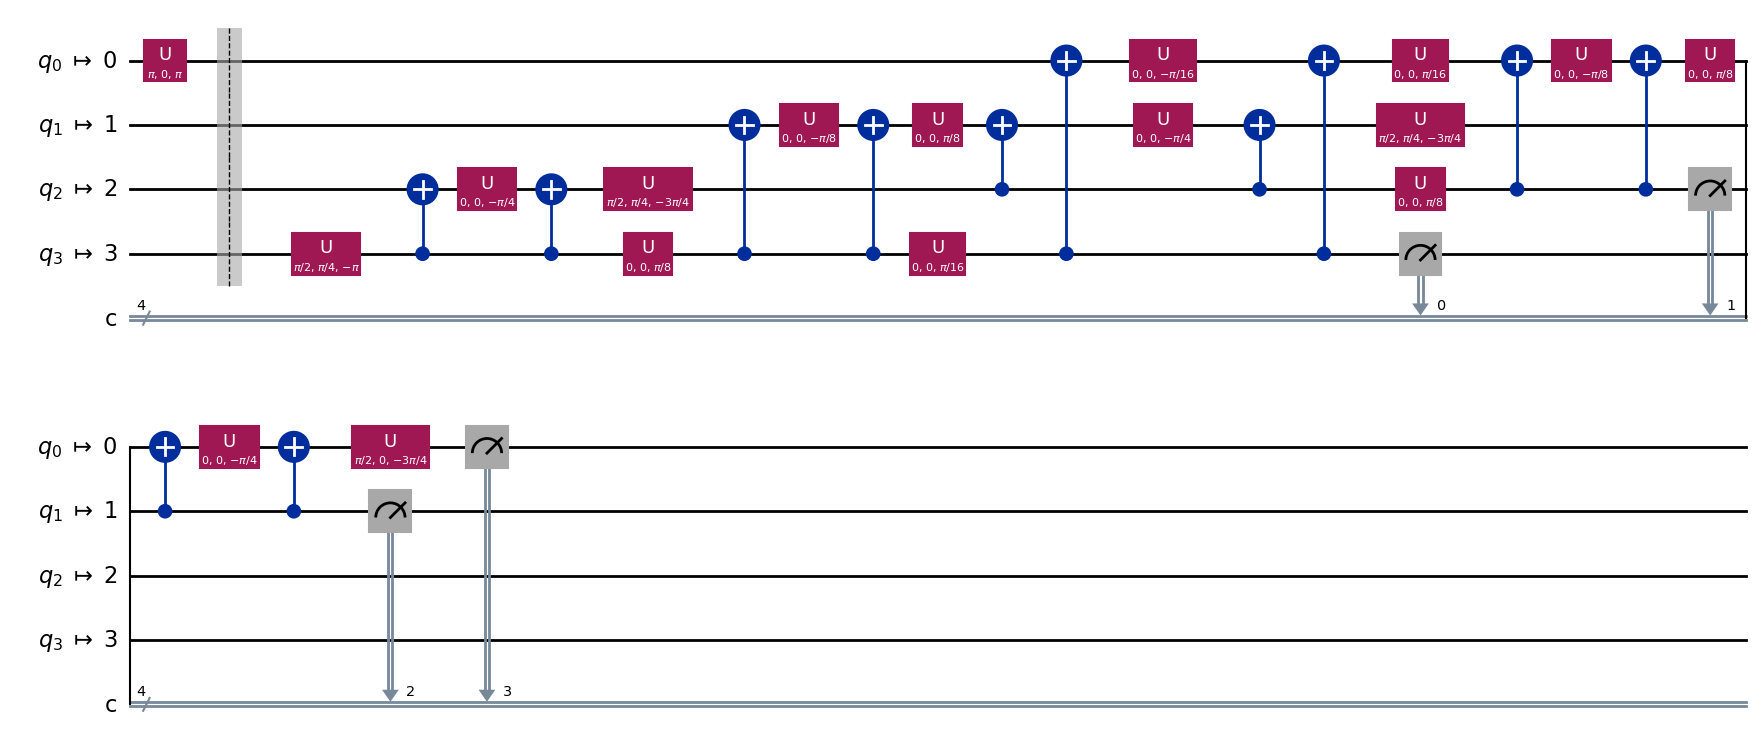

In [34]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFTGate
from qiskit import transpile

bits=4
qrec_q=QuantumRegister(bits+1, 'q')
crec_c=ClassicalRegister(bits, 'c')
qc=QuantumCircuit(qrec_q, crec_c)

qc.x(qrec_q[0])

qc.barrier()
    
qc=qc.compose(QFTGate(bits),[x for x in range(bits)])
qc.barrier
qc.measure(range(bits), range(bits))
qc=transpile(qc, basis_gates=['u', 'cx'])




qc.draw(output="mpl", idle_wires=False, style="iqp")

{'1110': 67, '0101': 65, '0110': 63, '1010': 62, '1011': 69, '1000': 67, '1101': 57, '0111': 52, '1100': 63, '0010': 68, '1001': 64, '0011': 69, '0100': 62, '1111': 67, '0001': 61, '0000': 44}


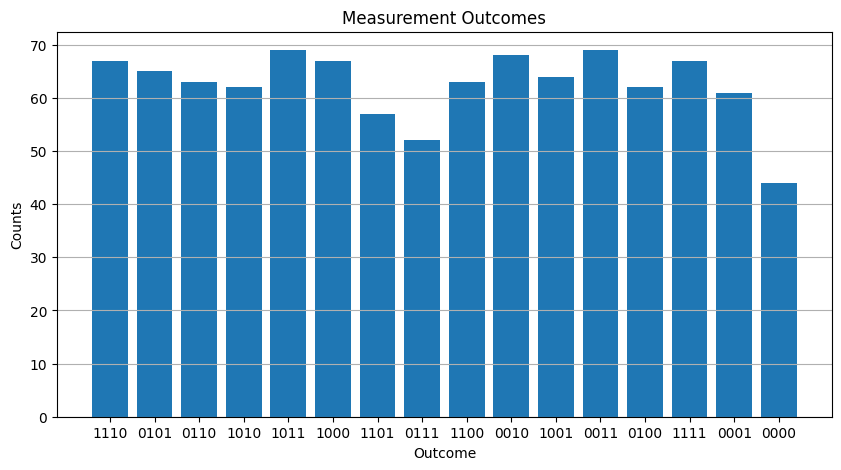

In [35]:
from qiskit_aer import AerSimulator, StatevectorSimulator
from matplotlib import pyplot as pyplot

simulator = AerSimulator()
complied_circuit = transpile(qc, simulator)
result = simulator.run(complied_circuit, shots=1000).result()
counts = result.get_counts(complied_circuit)
statevector = StatevectorSimulator().run(complied_circuit).result().get_statevector()

print(counts)

plt.subplots(figsize=(10,5))

plt.bar(counts.keys(),counts.values())
plt.xlabel('Outcome')
plt.ylabel('Counts')
plt.title('Measurement Outcomes')
plt.grid(axis='y')





{'0000': 1000}


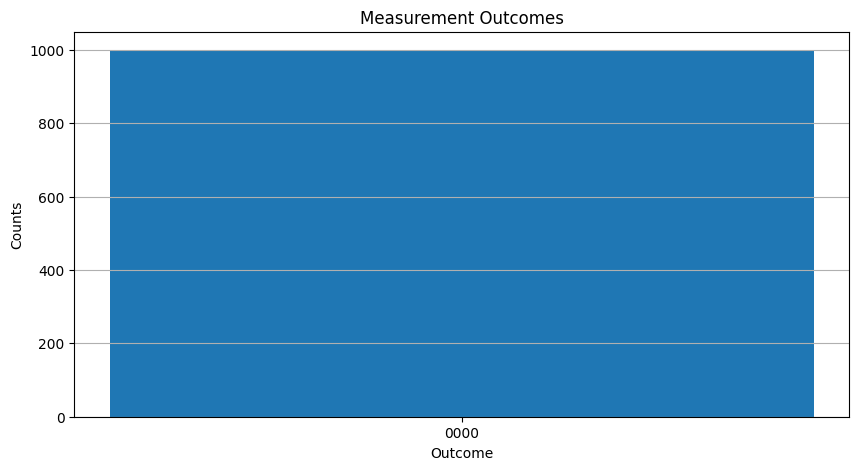

In [36]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFTGate
from qiskit import transpile
from qiskit_aer import AerSimulator, StatevectorSimulator
from matplotlib import pyplot as pyplot

bits=4
qrec_q=QuantumRegister(bits+1, 'q')
crec_c=ClassicalRegister(bits, 'c')
qc=QuantumCircuit(qrec_q, crec_c)

qc.h(x for x in range(bits))
qc.barrier()
    
qc=qc.compose(QFTGate(bits),[x for x in range(bits)])
qc.barrier
qc.measure(range(bits), range(bits))
qc=transpile(qc, basis_gates=['u', 'cx'])



simulator = AerSimulator()
complied_circuit = transpile(qc, simulator)
result = simulator.run(complied_circuit, shots=1000).result()
counts = result.get_counts(complied_circuit)
statevector = StatevectorSimulator().run(complied_circuit).result().get_statevector()

print(counts)

plt.subplots(figsize=(10,5))

plt.bar(counts.keys(),counts.values())
plt.xlabel('Outcome')
plt.ylabel('Counts')
plt.title('Measurement Outcomes')
plt.grid(axis='y')




MockSimulator

In [37]:
from qiskit_aer import AerSimulator
from qiskit import transpile

class MockSimulator:
    def __init__(self, shots=1024, seed=32):
        self.shots = shots
        self.seed = seed
        self.backend = AerSimulator()

    def run(self, circuit):
        
        compiled = transpile(circuit, self.backend)

        job = self.backend.run(compiled, shots=self.shots, seed=self.seed)
        result = job.result()

        return result.get_counts()

    def statevector(self, circuit):
        
        backend = AerSimulator(method="statevector")

        compiled = transpile(circuit, backend)
        job = backend.run(compiled)
        result = job.result()

        return result.get_statevector()

{'1': 497, '0': 503}


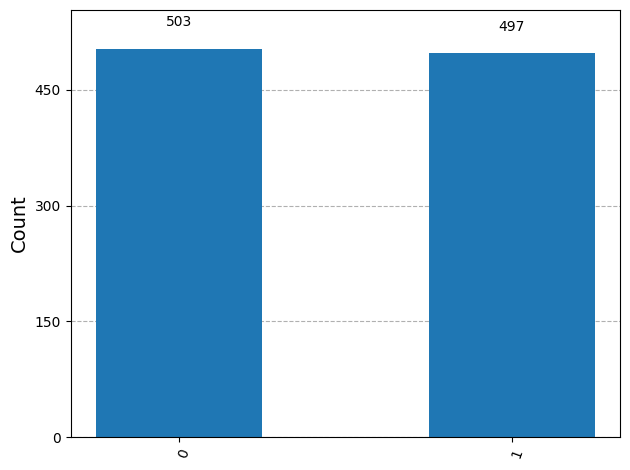

In [38]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()

sim = MockSimulator(shots=1000, seed=32)
counts = sim.run(qc)

print(counts)
plot_histogram(counts)

{'0001': 66, '1010': 55, '0000': 58, '0011': 67, '1101': 67, '1111': 67, '0111': 63, '1011': 67, '0100': 66, '0110': 56, '0010': 66, '1001': 56, '0101': 62, '1000': 59, '1110': 60, '1100': 65}


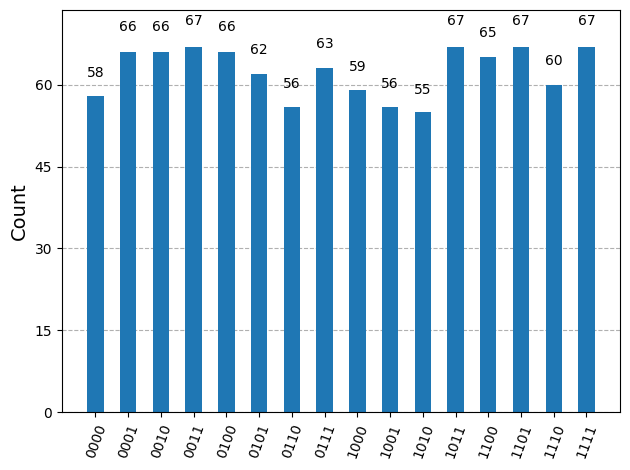

In [39]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFTGate
from qiskit import transpile

bits=4
qrec_q=QuantumRegister(bits+1, 'q')
crec_c=ClassicalRegister(bits, 'c')
qc=QuantumCircuit(qrec_q, crec_c)

qc.x(qrec_q[0])

qc.barrier()
    
qc=qc.compose(QFTGate(bits),[x for x in range(bits)])
qc.barrier
qc.measure(range(bits), range(bits))
qc=transpile(qc, basis_gates=['u', 'cx'])




sim = MockSimulator(shots=1000, seed=82)
counts = sim.run(qc)

print(counts)
plot_histogram(counts)




{'0000': 1000}


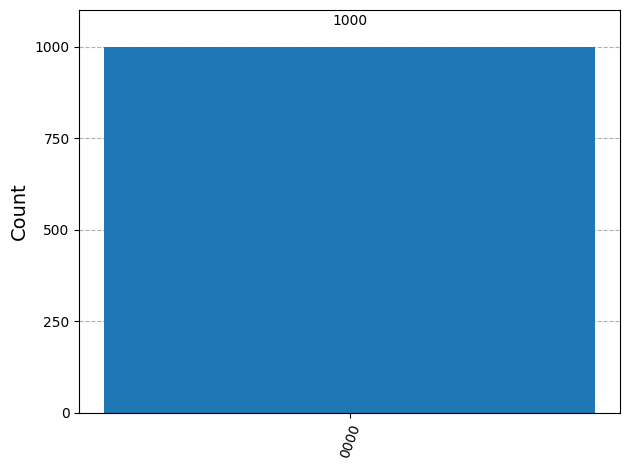

In [40]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFTGate
from qiskit import transpile

bits=4
qrec_q=QuantumRegister(bits+1, 'q')
crec_c=ClassicalRegister(bits, 'c')
qc=QuantumCircuit(qrec_q, crec_c)

qc.h(x for x in range(bits))

qc.barrier()
    
qc=qc.compose(QFTGate(bits),[x for x in range(bits)])
qc.barrier
qc.measure(range(bits), range(bits))
qc=transpile(qc, basis_gates=['u', 'cx'])




sim = MockSimulator(shots=1000, seed=32)
counts = sim.run(qc)

print(counts)
plot_histogram(counts)

In [41]:
import pytest
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile

class MockSimulator:
    def __init__(self, shots=1024, seed=32):
        self.shots = shots
        self.seed = seed
        self.backend = AerSimulator()

    def run(self, circuit):
        
        compiled = transpile(circuit, self.backend)

        job = self.backend.run(compiled, shots=self.shots, seed=self.seed)
        result = job.result()

        return result.get_counts()

    def statevector(self, circuit):
        
        backend = AerSimulator(method="statevector")

        compiled = transpile(circuit, backend)
        job = backend.run(compiled)
        result = job.result()

        return result.get_statevector()





def test_hadamard():
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.measure_all()

    sim = MockSimulator(shots=1000)
    counts = sim.run(qc)

    assert abs(counts['0'] - counts['1']) < 200
    print("test_hadamard passed")


def test_bell_state():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure_all()

    sim = MockSimulator(shots=1000)
    counts = sim.run(qc)

    assert '00' in counts
    assert '11' in counts
    print("test_bell_state passed")


test_hadamard()
test_bell_state()


test_hadamard passed
test_bell_state passed


In [42]:
import numpy as np

class SimulatorA:
    def __init__(self, shots=1024, seed=32):
        self.shots = shots
        self.seed = seed
        pass

    def u_gate(self, theta):
        return np.array([[1, 0], [0, np.exp(1j*theta)]])
    

    def apply_single_qubit_gate(self, state, gate, target, n):
        I = np.eye(2)
        ops = [I] * n
        ops[target] = gate

        full_op = ops[0]
        for op in ops[1:]:
            full_op = np.kron(full_op, op)

        return full_op @ state
    
    
    def apply_cx(self, state, control, target, n):
        new_state = np.zeros_like(state)

        for i in range(len(state)):
            bits = list(format(i, f'0{n}b'))

            if bits[n - 1 - control] == '1':
                target_index = n - 1 - target
                bits[target_index] = '0' if bits[target_index] == '1' else '1'

            j = int("".join(bits), 2)
            new_state[j] += state[i]

            return new_state

    def run(self, circuit):
        n = circuit.num_qubits
        state = np.zeros(2**n, dtype=complex)
        state[0] = 1  # |0...0>

        for operation, qubits, _ in circuit.data:
            name = operation.name

            #if name == 'h':
             #   state = self.apply_single_qubit_gate(state, self.h_gate(), qubits[0].index, n)

            #elif name == 'x':
             #   state = self.apply_single_qubit_gate(state, self.x_gate(), qubits[0].index, n)

            #elif name == 'y':
              #  state = self.apply_single_qubit_gate(state, self.y_gate(), qubits[0].index, n)

            #elif name == 'z':
             #   state = self.apply_single_qubit_gate(state, self.z_gate(), qubits[0].index, n)

            if name == 'u':
                state = self.apply_single_qubit_gate(state, self.u_gate(), qubits[0].index, n, theta)

            elif name == 'cx':
                control = qubits[0].index
                target = qubits[1].index
                state = self.apply_cx(state, control, target, n)

            probs = np.abs(state)**2
            return probs

    #def h_gate(self):
        return np.array([[1, 1], [1, -1]]) / np.sqrt(2)

    #def x_gate(self):
        return np.array([[0, 1], [1, 0]])
    
    #def y_gate(self):
        return np.array([[0, -1j], [1j, 0]])
    
    #def z_gate(self):
        return np.array([[1, 0], [0, -1]])
    
    
   

        

In [43]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFTGate
from qiskit import transpile

bits=4
qrec_q=QuantumRegister(bits+1, 'q')
crec_c=ClassicalRegister(bits, 'c')
qc=QuantumCircuit(qrec_q, crec_c)

qc.h(x for x in range(bits))

qc.barrier()
    
qc=qc.compose(QFTGate(bits),[x for x in range(bits)])
qc.barrier
qc.measure(range(bits), range(bits))
qc=transpile(qc, basis_gates=['u', 'cx'])




sim = SimulatorA(shots=1000, seed=32)
probs = sim.run(qc)

shots = 1000
counts = {}

for i, p in enumerate(probs):
    if p > 1e-6:
        bitstring = format(i, f'0{n}b')
        counts[bitstring] = int(p * shots)


plt.bar(counts.keys(), counts.values())
plt.xlabel("States")
plt.ylabel("Counts")
plt.title("QFT Output Distribution")
plt.show()

C:\Users\akibu\AppData\Local\Temp\ipykernel_1732\1042771373.py:45: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for operation, qubits, _ in circuit.data:


TypeError: SimulatorA.u_gate() missing 1 required positional argument: 'theta'

In [45]:
import numpy as np

n=4
psi=np.zeros(2**n, dtype=complex)
psi[0]=1
arr = np.zeros([2]*n)

X = np.zeros([2]*2)
X[0,1]=1
X[1,0]=1
print(X)




[[0. 1.]
 [1. 0.]]
